<a href="https://colab.research.google.com/github/Sneha8126/ML-Projects/blob/main/ClassificationandDeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Heart_Disease_Prediction.csv')
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [ ]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Heart Disease"].value_counts()

,count
Heart Disease,
Absence,150
Presence,120


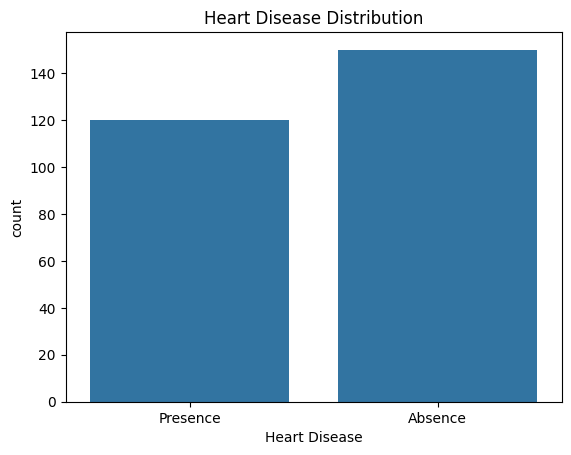

In [ ]:
sns.countplot(data=df, x="Heart Disease")
plt.title("Heart Disease Distribution")
plt.show()

In [ ]:
df["Heart Disease"] = df["Heart Disease"].map({
    "Presence":1,
    "Absence":0
})

In [ ]:
df["Heart Disease"].value_counts()

,count
Heart Disease,
0,150
1,120


In [ ]:
X = df.drop("Heart Disease", axis=1)

y = df["Heart Disease"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
train_pred = log_model.predict(X_train)
test_pred = log_model.predict(X_test)

In [ ]:
y_pred = log_model.predict(X_test)

In [ ]:
y_prob = log_model.predict_proba(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8518518518518519


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[24  6]
 [ 2 22]]


In [ ]:
from sklearn.metrics import precision_score

precision_score(y_test, y_pred)

0.7857142857142857

In [ ]:
from sklearn.metrics import recall_score

recall_score(y_test, y_pred)

0.9166666666666666

In [ ]:
print('Train Confusion Matrix :-\n',confusion_matrix(y_train,train_pred))
print('Train Accuracfy :-',accuracy_score(y_train,train_pred))
print('Train Precision Score :-',precision_score(y_train,train_pred))
print('Train Recall Score :-',recall_score(y_train,train_pred))

Train Confusion Matrix :-
 [[107  13]
 [ 19  77]]
Train Accuracfy :- 0.8518518518518519
Train Precision Score :- 0.8555555555555555
Train Recall Score :- 0.8020833333333334


In [ ]:
print('Test confusion matrix :-\n',confusion_matrix(y_test,test_pred))
print('Test Accuracy :-',accuracy_score(y_test,test_pred))
print('Test Precision Score :-',precision_score(y_test,test_pred))
print('Test Recall Score :-',recall_score(y_test,test_pred))

Test confusion matrix :-
 [[24  6]
 [ 2 22]]
Test Accuracy :- 0.8518518518518519
Test Precision Score :- 0.7857142857142857
Test Recall Score :- 0.9166666666666666


# D-Tree Implementation

In [ ]:
# D-Tree Implementation
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
train_pred = dt_model.predict(X_train)

test_pred = dt_model.predict(X_test)

In [ ]:

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

In [ ]:
print("Train Confusion Matrix:\n",confusion_matrix(y_train,train_pred))

print("Train Accuracy :",accuracy_score(y_train,train_pred))

print("Train Precision :",precision_score(y_train,train_pred))

print("Train Recall :",recall_score(y_train,train_pred))

print("Train F1 Score :",f1_score(y_train,train_pred))

Train Confusion Matrix:
 [[120   0]
 [  0  96]]
Train Accuracy : 1.0
Train Precision : 1.0
Train Recall : 1.0
Train F1 Score : 1.0


In [ ]:
print("Test Confusion Matrix:\n",confusion_matrix(y_test,test_pred))

print("Test Accuracy :",accuracy_score(y_test,test_pred))

print("Test Precision :",precision_score(y_test,test_pred))

print("Test Recall :",recall_score(y_test,test_pred))

print("Test F1 Score :",f1_score(y_test,test_pred))

Test Confusion Matrix:
 [[23  7]
 [ 4 20]]
Test Accuracy : 0.7962962962962963
Test Precision : 0.7407407407407407
Test Recall : 0.8333333333333334
Test F1 Score : 0.7843137254901961


# Random Forest

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score,classification_report

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

prediction = rf_model.predict(X_test)

In [ ]:
print("Train Confusion Matrix:\n",confusion_matrix(y_train,train_pred))

print("Train Accuracy :",accuracy_score(y_train,train_pred))

print("Train Precision :",precision_score(y_train,train_pred))

print("Train Recall :",recall_score(y_train,train_pred))

print("Train F1 Score :",f1_score(y_train,train_pred))

Train Confusion Matrix:
 [[120   0]
 [  0  96]]
Train Accuracy : 1.0
Train Precision : 1.0
Train Recall : 1.0
Train F1 Score : 1.0


In [ ]:
print("Test Confusion Matrix:\n",confusion_matrix(y_test,test_pred))

print("Test Accuracy :",accuracy_score(y_test,test_pred))

print("Test Precision :",precision_score(y_test,test_pred))

print("Test Recall :",recall_score(y_test,test_pred))

print("Test F1 Score :",f1_score(y_test,test_pred))

Test Confusion Matrix:
 [[23  7]
 [ 4 20]]
Test Accuracy : 0.7962962962962963
Test Precision : 0.7407407407407407
Test Recall : 0.8333333333333334
Test F1 Score : 0.7843137254901961


In [ ]:
# Logistic Regression
log_pred = log_model.predict(X_test)

# Decision Tree
dt_pred = dt_model.predict(X_test)

# Random Forest
rf_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1-Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparison_df = comparison_df.round(4)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8519,0.7857,0.9167,0.8462
1,Decision Tree,0.7963,0.7407,0.8333,0.7843
2,Random Forest,0.8148,0.7692,0.8333,0.8000


# Deep Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
X.shape

(270, 13)

In [ ]:
model = Sequential()

model.add(Dense(32, activation="relu", input_shape=(13,)))

model.add(Dense(16, activation="relu"))

model.add(Dense(8, activation="relu"))

model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.fit(X_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.6570 - loss: 0.6596 - val_accuracy: 0.6136 - val_loss: 0.6543
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7035 - loss: 0.6273 - val_accuracy: 0.6364 - val_loss: 0.6303
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7267 - loss: 0.6004 - val_accuracy: 0.6591 - val_loss: 0.6091
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7442 - loss: 0.5740 - val_accuracy: 0.6591 - val_loss: 0.5898
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7733 - loss: 0.5461 - val_accuracy: 0.7045 - val_loss: 0.5713
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8023 - loss: 0.5190 - val_accuracy: 0.7727 - val_loss: 0.5511
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8023 - loss: 0.4947 - val_accuracy: 0.7727 - val_loss: 0.5312
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8198 - loss: 0.4697 - val_accuracy: 0.8182 - val_loss:

In [ ]:
print('Train accu :-',accuracy_score(y_train,train_pred))
print('Test accu :-',accuracy_score(y_test,test_pred))

Train accu :- 1.0
Test accu :- 0.7962962962962963


In [ ]:
print(confusion_matrix(y_train,train_pred))

[[120   0]
 [  0  96]]


In [ ]:
print(confusion_matrix(y_test,test_pred))

[[23  7]
 [ 4 20]]
